# Exploratory Data Analysis (EDA)  
### Dataset: NYC Yellow Taxi Trip Data — January 2015  
The chosen dataset is ["NYC Yellow Taxi Trip Data" by Elemento](https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data) on Kaggle, and keeps data from New York City's Taxi & Limousine Commission (TLC), for the months of Jan 2015 & Jan-Mar 2016. In this analysis, we will handle only the data from Jan 2015.  

## Used libraries:

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
import shutil
from tqdm import tqdm
from datetime import datetime

/home/hugo/code/python/yellow-taxi-trip-data/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data ingestion  
We will use the kagglehub library to download the dataset directly from the author's repository on Kaggle.

In [2]:
dataset = "elemento/nyc-yellow-taxi-trip-data"
file = "yellow_tripdata_2015-01.csv"
bronze_path = Path().cwd().parent / "data" / "bronze" / file

if not bronze_path.exists():
    dataset_path = Path(kagglehub.dataset_download(dataset, file))
    shutil.copy(dataset_path, bronze_path)

In [3]:
lf = pl.scan_csv(bronze_path)
lf.head().collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,str,str,i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
2,"""2015-01-15 19:05:39""","""2015-01-15 19:23:42""",1,1.59,-73.993896,40.750111,1,"""N""",-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,"""2015-01-10 20:33:38""","""2015-01-10 20:53:28""",1,3.3,-74.001648,40.724243,1,"""N""",-73.994415,40.759109,1,14.5,0.5,0.5,2.0,0.0,0.3,17.8
1,"""2015-01-10 20:33:38""","""2015-01-10 20:43:41""",1,1.8,-73.963341,40.802788,1,"""N""",-73.95182,40.824413,2,9.5,0.5,0.5,0.0,0.0,0.3,10.8
1,"""2015-01-10 20:33:39""","""2015-01-10 20:35:31""",1,0.5,-74.009087,40.713818,1,"""N""",-74.004326,40.719986,2,3.5,0.5,0.5,0.0,0.0,0.3,4.8
1,"""2015-01-10 20:33:39""","""2015-01-10 20:52:58""",1,3.0,-73.971176,40.762428,1,"""N""",-74.004181,40.742653,2,15.0,0.5,0.5,0.0,0.0,0.3,16.3


## 1.1. Columns description  
**Source:** NYC Taxi & Limousine Commission (TLC) — [Official Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

Data was collected by authorized technology providers (TPEP) and submitted to the TLC. Each row represents a single yellow taxi trip in New York City.  
| Column | Expected type | Description | Possible values |
|---|---|---|---|
| `VendorID` | `int` | Code identifying the TPEP provider that generated the trip record | `1` = Creative Mobile Technologies · `2` = VeriFone Inc. |
| `tpep_pickup_datetime` | `datetime` | Date and time when the meter was engaged (trip start) | — |
| `tpep_dropoff_datetime` | `datetime` | Date and time when the meter was disengaged (trip end) | — |
| `passenger_count` | `int` | Number of passengers in the vehicle, as reported by the driver | Integer ≥ 0 |
| `trip_distance` | `float` | Trip distance in miles as reported by the taximeter | Decimal ≥ 0 |
| `pickup_longitude` | `float` | GPS longitude of the pickup location | Decimal — NYC range: −74.3 to −73.7 |
| `pickup_latitude` | `float` | GPS latitude of the pickup location | Decimal — NYC range: 40.5 to 40.9 |
| `RateCodeID` | `int` | Final rate code in effect at the end of the trip | `1` = Standard rate · `2` = JFK · `3` = Newark · `4` = Nassau or Westchester · `5` = Negotiated fare · `6` = Group ride |
| `store_and_fwd_flag` | `str` | Indicates whether the trip record was held in vehicle memory before being sent to the vendor due to lack of server connection | `Y` = Store and forward trip · `N` = Not a store and forward trip |
| `dropoff_longitude` | `float` | GPS longitude of the dropoff location | Decimal — NYC range: −74.3 to −73.7 |
| `dropoff_latitude` | `float` | GPS latitude of the dropoff location | Decimal — NYC range: 40.5 to 40.9 |
| `payment_type` | `int` | Numeric code indicating how the passenger paid for the trip | `1` = Credit card · `2` = Cash · `3` = No charge · `4` = Dispute · `5` = Unknown · `6` = Voided trip |
| `fare_amount` | `float` | Time-and-distance fare calculated by the meter, in USD | Decimal ≥ 0 |
| `extra` | `float` | Miscellaneous extras and surcharges. In 2015, only includes the $0.50 rush hour and $1.00 overnight charges | `0.0`, `0.5`, or `1.0` |
| `mta_tax` | `float` | MTA tax automatically triggered based on the metered rate in use | `$0.50` per trip |
| `tip_amount` | `float` | Tip amount — automatically populated for credit card payments. Cash tips are **not** included | Decimal ≥ 0 |
| `tolls_amount` | `float` | Total amount of all tolls paid during the trip | Decimal ≥ 0 |
| `improvement_surcharge` | `float` | Improvement surcharge assessed at the flag drop, introduced on January 1, 2015 to fund accessibility improvements in taxis | `$0.30` per trip |
| `total_amount` | `float` | Total amount charged to the passenger. Does **not** include cash tips | Decimal ≥ 0 |

> **Note on coordinates:** The 2015 version of this dataset records location as raw GPS coordinates (`longitude`/`latitude`). Later versions of the TLC dataset replaced these columns with `PULocationID`/`DOLocationID` (TLC Taxi Zone IDs).

> **Note on `VendorID`:** The current TLC data dictionary lists additional vendors (Curb Mobility, Myle Technologies, Helix), but in January 2015 only providers `1` (Creative Mobile Technologies) and `2` (VeriFone Inc.) were active.

## 2. Initial diagnosis

In [4]:
lf.describe()

statistic,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
str,f64,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.2748986e7,"""12748986""","""12748986""",1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,"""12748986""",1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748983e7,1.2748986e7
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
"""mean""",1.521437,null,null,1.681491,13.45913,-72.561838,39.972823,1.036901,null,-72.609039,39.999614,1.386712,11.905659,0.308279,0.497799,1.853814,0.243498,0.283143,15.108295
"""std""",0.49954,null,null,1.337924,9844.094218,10.125104,5.578691,0.673224,null,9.966037,5.487742,0.498861,10.302537,0.591664,0.035342,1106.432314,1.527171,0.069086,1106.503247
"""min""",1.0,"""2015-01-01 00:00:00""","""2015-01-01 00:00:00""",0.0,0.0,-121.925812,0.0,1.0,"""N""",-740.166687,-9.029157,1.0,-450.0,-79.0,-0.5,-92.42,-26.0,0.0,-450.3
"""25%""",1.0,null,null,1.0,1.0,-73.991684,40.735542,1.0,null,-73.991196,40.73436,1.0,6.5,0.0,0.5,0.0,0.0,0.3,8.16
"""50%""",2.0,null,null,1.0,1.68,-73.981598,40.753143,1.0,null,-73.979759,40.753624,1.0,9.0,0.0,0.5,1.0,0.0,0.3,11.16
"""75%""",2.0,null,null,2.0,3.0,-73.966621,40.76757,1.0,null,-73.962456,40.768803,2.0,13.5,0.5,0.5,2.06,0.0,0.3,16.3
"""max""",2.0,"""2015-01-31 23:59:59""","""2016-02-02 16:30:52""",9.0,1.5420e7,78.662651,404.700012,99.0,"""Y""",85.274025,459.533325,5.0,4008.0,999.99,0.5,3950588.8,1450.09,0.3,3950611.6


## 2.1. passenger_count

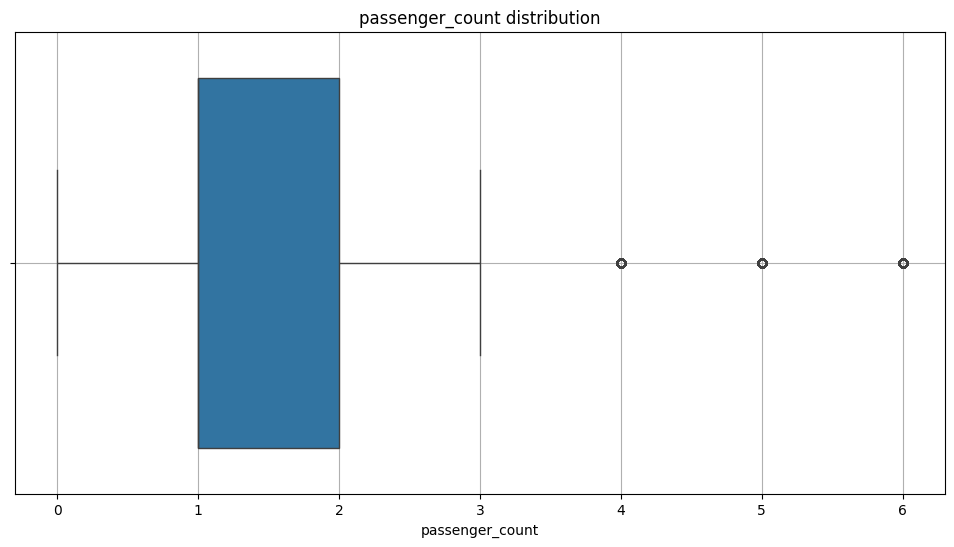

In [5]:
passenger_count = lf.select("passenger_count").collect().sample(10000)

plt.figure(figsize=(12, 6))
sns.boxplot(data=passenger_count, x="passenger_count")
plt.title("passenger_count distribution")
plt.grid(True)
plt.show()

## 2.2. trip_distance

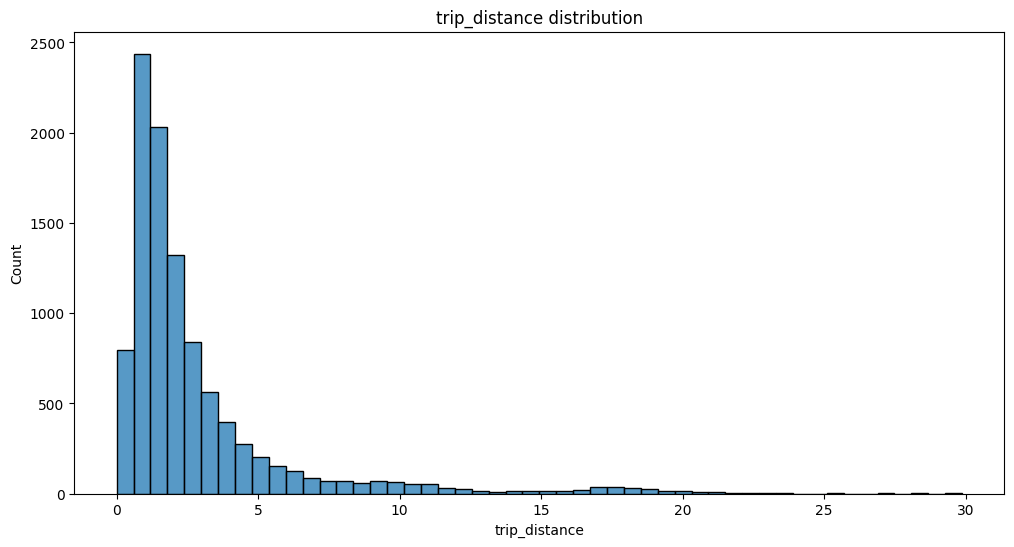

In [7]:
trip_distance = (
    lf.select("trip_distance")
    .filter(pl.col("trip_distance").is_between(0, 50))
    .collect()
    .sample(10000)
)

plt.figure(figsize=(12, 6))
sns.histplot(data=trip_distance, x="trip_distance", bins=50)
plt.title("trip_distance distribution")
plt.show()

## 2.3. Boarding and disembarking coordinates

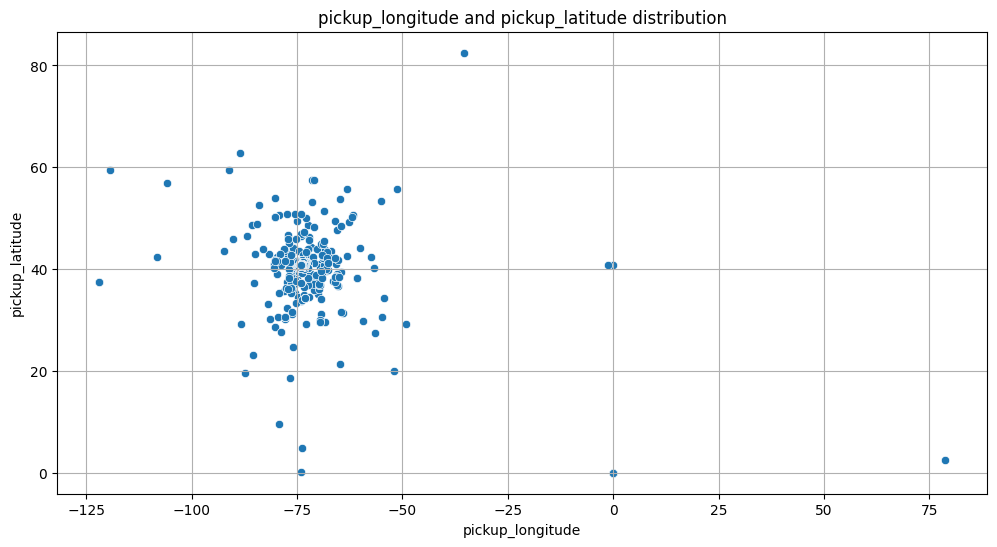

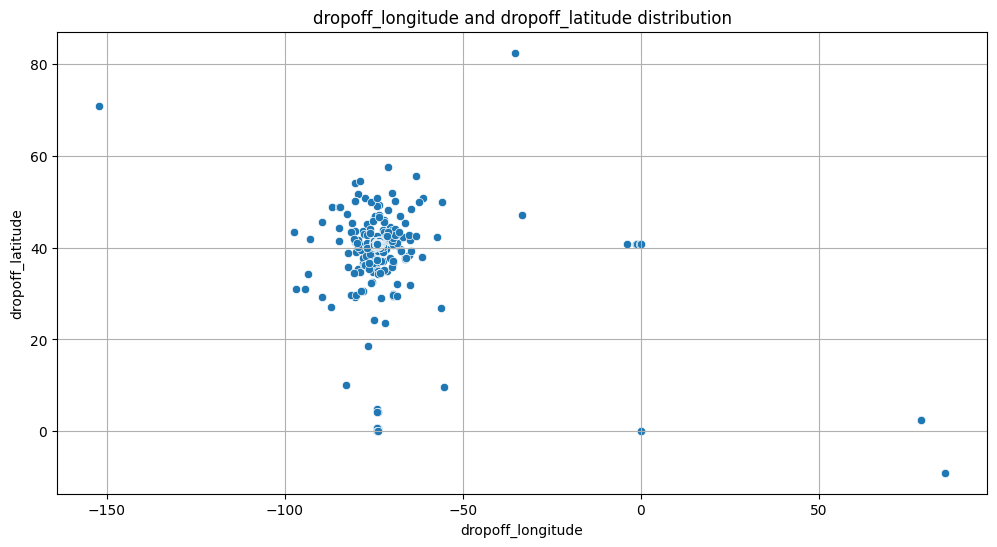

In [11]:
for longitude, latitude in [
    ("pickup_longitude", "pickup_latitude"),
    ("dropoff_longitude", "dropoff_latitude")
]:
    df_coords = (
        lf.filter(pl.col(longitude).is_between(-180, 180))
        .filter(pl.col(latitude).is_between(-90, 90))
        .select([longitude, latitude])
        .collect()
    )

    plt.figure(figsize=(12,6))
    sns.scatterplot(data=df_coords, x=longitude, y=latitude)
    plt.title(f"{longitude} and {latitude} distribution")
    plt.grid(True)
    plt.show()

## 2.4. fare_amount

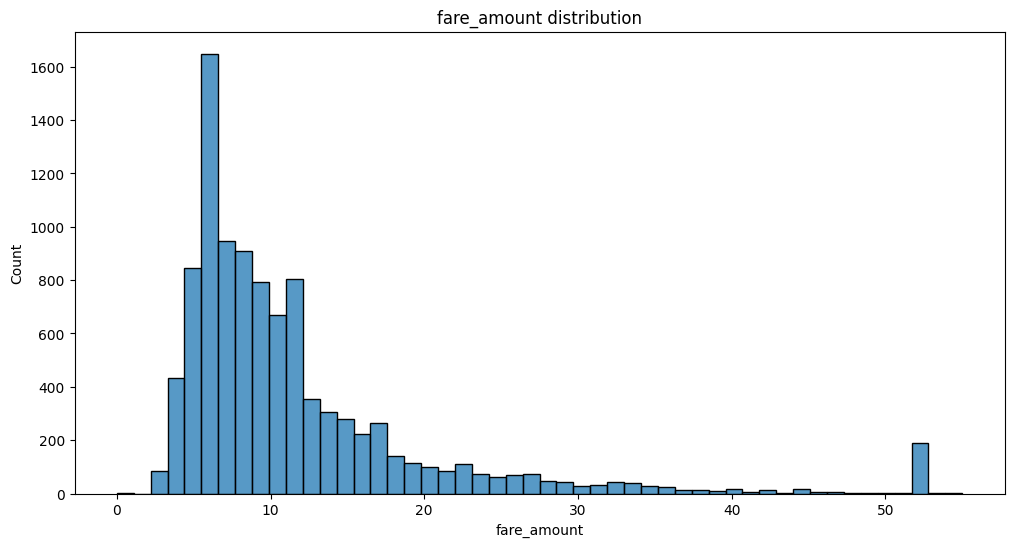

In [12]:
fare_amount = (
    lf.select("fare_amount")
    .filter(pl.col("fare_amount").is_between(0, 55))
    .collect()
    .sample(10000)
)

plt.figure(figsize=(12, 6))
sns.histplot(data=fare_amount, x="fare_amount", bins=50)
plt.title("fare_amount distribution")
plt.show()

## 2.5. extra

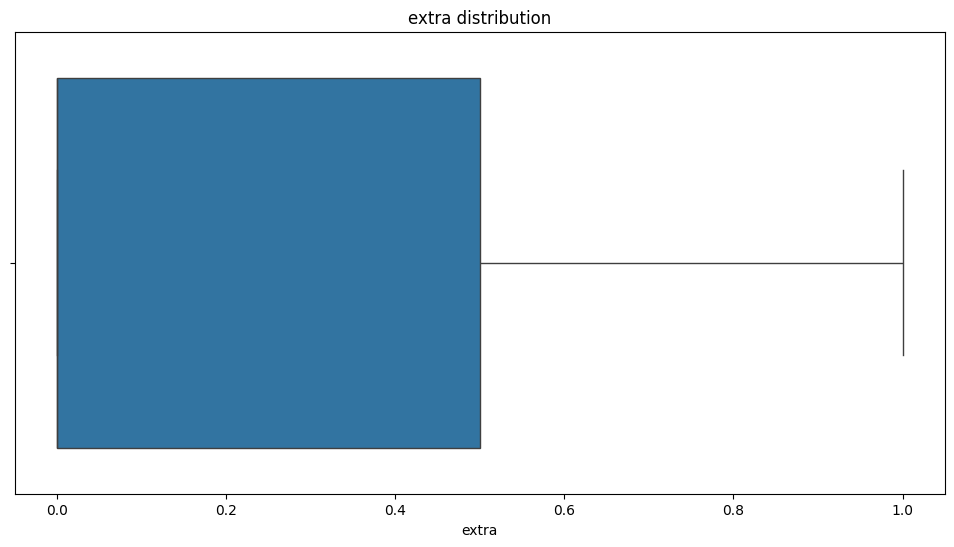

In [15]:
extra = (
    lf.select("extra")
    .filter(pl.col("extra").is_between(0, 10))
    .collect()
    .sample(10000)
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=extra, x="extra")
plt.title("extra distribution")
plt.show()

## 2.6. tip_amount

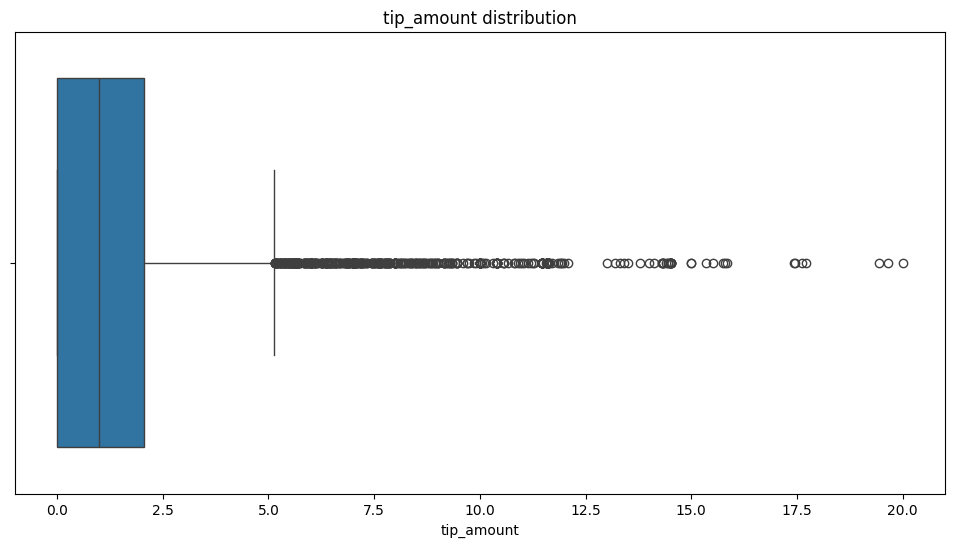

In [17]:
tip_amount = (
    lf.select("tip_amount")
    .filter(pl.col("tip_amount").is_between(0, 20))
    .collect()
    .sample(10000)
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=tip_amount, x="tip_amount")
plt.title("tip_amount distribution")
plt.show()

## 2.7. tolls_amount

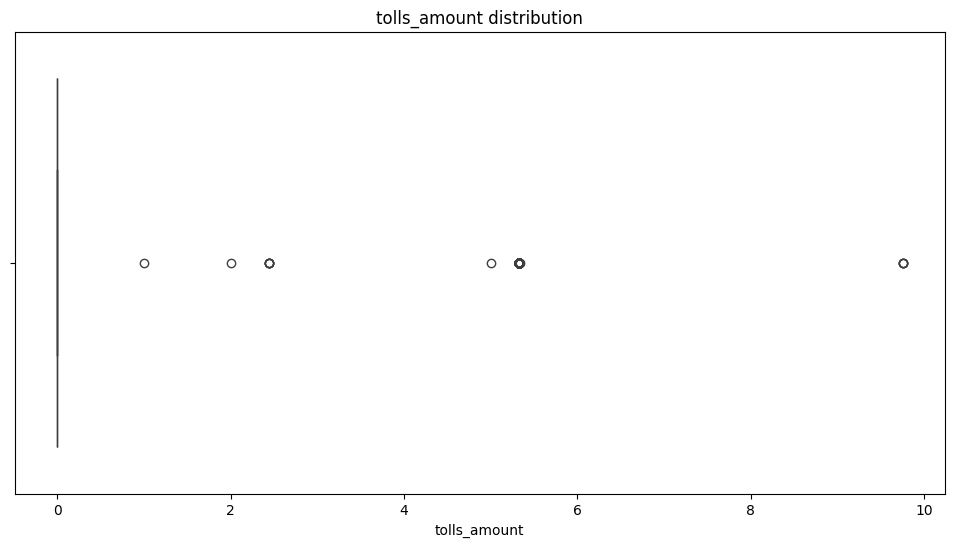

In [19]:
tolls_amount = (
    lf.select("tolls_amount")
    .filter(pl.col("tolls_amount").is_between(0, 10))
    .collect()
    .sample(10000)
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=tolls_amount, x="tolls_amount")
plt.title("tolls_amount distribution")
plt.show()

In [12]:
lf.filter(pl.col("improvement_surcharge").is_null()).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,str,str,i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
1,"""2015-01-02 08:46:23""","""2015-01-02 09:09:26""",1,3.6,0.0,0.0,1,"""N""",0.0,0.0,1,17.0,0.0,0.5,3.5,0.0,null,21.0
1,"""2015-01-02 09:13:32""","""2015-01-02 09:35:25""",1,2.2,0.0,0.0,1,"""N""",0.0,0.0,1,14.5,0.0,0.5,3.0,0.0,null,18.0
1,"""2015-01-02 09:52:43""","""2015-01-02 10:22:02""",1,2.1,0.0,0.0,1,"""N""",0.0,0.0,1,18.0,0.0,0.5,3.7,0.0,null,22.2


In [13]:
lf.filter((pl.col("trip_distance") == 0) | (pl.col("total_amount") == 0)).head().collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,str,str,i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
1,"""2015-01-15 10:26:16""","""2015-01-15 10:26:42""",2,0.0,-73.987656,40.743645,5,"""N""",-73.987488,40.743484,1,60.0,0.0,0.0,15.0,0.0,0.3,75.3
1,"""2015-01-15 10:26:17""","""2015-01-15 10:27:28""",1,0.0,-73.946526,40.744991,1,"""N""",-73.946526,40.744991,2,3.0,0.0,0.5,0.0,0.0,0.3,3.8
1,"""2015-01-01 01:08:56""","""2015-01-01 01:08:56""",4,0.0,-73.980789,40.676605,1,"""Y""",0.0,0.0,2,20.0,0.5,0.5,0.0,0.0,0.0,21.3
2,"""2015-01-25 17:45:15""","""2015-01-25 17:45:21""",1,0.0,-73.975655,40.761318,2,"""N""",0.0,0.0,1,52.0,0.0,0.5,20.0,0.0,0.3,72.8
1,"""2015-01-10 20:14:23""","""2015-01-10 20:14:36""",1,0.0,-73.993271,40.748833,1,"""N""",-73.993271,40.748833,3,2.5,0.5,0.5,0.0,0.0,0.3,3.8


## 3. Data transformation

In [4]:
df_silver = (
    lf.rename({
        "VendorID": "vendor_id",
        "RateCodeID": "rate_code_id"
    })
    .filter(pl.col("passenger_count").is_between(1, 4))
    .filter(pl.col("trip_distance") <= 10)
    .filter(pl.col("pickup_longitude").is_between(-74.3, -73.7))
    .filter(pl.col("pickup_latitude").is_between(40.5, 40.9))
    .filter(pl.col("rate_code_id").is_in(range(1,7)))
    .filter(pl.col("dropoff_longitude").is_between(-74.3, -73.7))
    .filter(pl.col("dropoff_latitude").is_between(40.5, 40.9))
    .filter(pl.col("fare_amount").is_between(0, 55))
    .filter(pl.col("extra").is_between(0, 2))
    .filter(pl.col("mta_tax") >= 0)
    .filter(pl.col("tip_amount").is_between(0, 5))
    .filter(pl.col("tolls_amount").is_between(0, 1))
    .filter(pl.col("total_amount") >= 0)
    .drop_nulls()
    .with_columns(
        tpep_pickup_datetime = pl.col("tpep_pickup_datetime").str.to_datetime(),
        tpep_dropoff_datetime = pl.col("tpep_dropoff_datetime").str.to_datetime()
    )
    .filter(
        (pl.col("tpep_pickup_datetime").is_between(
            datetime(2015, 1, 1), datetime(2015, 1, 31, 23, 59, 59)
        )) &
        (pl.col("tpep_dropoff_datetime").is_between(
            datetime(2015, 1, 1), datetime(2015, 1, 31, 23, 59, 59)
        ))
    )
    .collect()
)

bronze_size = lf.select(pl.len()).collect().item()
silver_size = df_silver.shape[0]

print(f"Bronze size: {bronze_size}")
print(f"Silver size: {silver_size}")
print(f"Filtered rows: {bronze_size - silver_size}")

Bronze size: 12748986
Silver size: 10420284
Filtered rows: 2328702


In [29]:
df_silver.head()

vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code_id,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,datetime[μs],datetime[μs],i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,"""N""",-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.3,-74.001648,40.724243,1,"""N""",-73.994415,40.759109,1,14.5,0.5,0.5,2.0,0.0,0.3,17.8
1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.8,-73.963341,40.802788,1,"""N""",-73.95182,40.824413,2,9.5,0.5,0.5,0.0,0.0,0.3,10.8
1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.5,-74.009087,40.713818,1,"""N""",-74.004326,40.719986,2,3.5,0.5,0.5,0.0,0.0,0.3,4.8
1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.0,-73.971176,40.762428,1,"""N""",-74.004181,40.742653,2,15.0,0.5,0.5,0.0,0.0,0.3,16.3


In [6]:
df_silver.describe()

statistic,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code_id,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
str,f64,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.0420284e7,"""10420284""","""10420284""",1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,"""10420284""",1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7,1.0420284e7
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.479352,"""2015-01-16 15:14:26.652914""","""2015-01-16 15:25:59.261830""",1.312355,2.011496,-73.979688,40.752653,1.00381,null,-73.977533,40.753003,1.398454,9.685435,0.313428,0.499525,1.168502,0.000018,0.281943,11.966443
"""std""",0.499573,null,null,0.661601,1.547926,0.021679,0.02345,0.116331,null,0.023368,0.026681,0.500901,4.978284,0.363086,0.015403,1.221319,0.003664,0.071351,5.53475
"""min""",1.0,"""2015-01-01 00:00:00""","""2015-01-01 00:00:00""",1.0,0.0,-74.298271,40.518974,1.0,"""N""",-74.298416,40.518974,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",1.0,"""2015-01-09 10:09:52""","""2015-01-09 10:23:36""",1.0,0.95,-73.992165,40.738068,1.0,null,-73.99157,40.737419,1.0,6.0,0.0,0.5,0.0,0.0,0.3,7.8
"""50%""",1.0,"""2015-01-16 12:22:02""","""2015-01-16 12:34:45""",1.0,1.53,-73.982307,40.754128,1.0,null,-73.980888,40.754639,1.0,8.5,0.0,0.5,1.0,0.0,0.3,10.56
"""75%""",2.0,"""2015-01-23 19:45:14""","""2015-01-23 19:57:22""",1.0,2.58,-73.969826,40.767494,1.0,null,-73.966476,40.768967,2.0,12.0,0.5,0.5,2.0,0.0,0.3,14.75
"""max""",2.0,"""2015-01-31 23:59:21""","""2015-01-31 23:59:59""",4.0,10.0,-73.700066,40.899952,6.0,"""Y""",-73.700012,40.899624,5.0,55.0,2.0,0.5,5.0,1.0,0.3,124.96


## 3.1. Feature Engineering

In [5]:
df_silver = (
    df_silver.with_columns(
        trip_duration_minutes =
            (pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
            .dt.total_seconds() / 60,
        hour_of_day =
            pl.col("tpep_pickup_datetime").dt.hour(),
        day_of_week =
            pl.col("tpep_pickup_datetime").dt.weekday()
    ).with_columns(
        speed_mph =
            pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60)
    )
)

df_silver.head().select(["trip_duration_minutes", "hour_of_day", "day_of_week", "speed_mph"])

trip_duration_minutes,hour_of_day,day_of_week,speed_mph
f64,i8,i8,f64
18.05,19,4,5.285319
19.833333,20,6,9.983193
10.05,20,6,10.746269
1.866667,20,6,16.071429
19.316667,20,6,9.318378


## 4. Silver data loading

In [7]:
silver_path = Path().cwd().parent / "data" / "silver" / bronze_path.with_suffix(".parquet").name

df_silver.write_parquet(silver_path)

## 5. Gold

In [8]:
lf_gold = pl.scan_parquet(silver_path)

gold_columns = {
    "vendor_id": {
        1: "Creative Mobile Technologies",
        2: "VeriFone Inc."
    },
    "rate_code_id": {
        1: "Standard rate",
        2: "JFK",
        3: "Newark",
        4: "Nassau or Westchester",
        5: "Negotiated fare",
        6: "Group ride",
    },
    "payment_type": {
        1: "Credit card",
        2: "Cash",
        3: "No charge",
        4: "Dispute",
        5: "Unknown",
        6: "Voided trip"
    }
}

for column, mapping in gold_columns.items():
    lf_gold = lf_gold.with_columns(
        pl.col(column).replace_strict(mapping).alias(column)
    )

lf_gold.select(gold_columns.keys()).head().collect()

vendor_id,rate_code_id,payment_type
str,str,str
"""VeriFone Inc.""","""Standard rate""","""Credit card"""
"""Creative Mobile Technologies""","""Standard rate""","""Credit card"""
"""Creative Mobile Technologies""","""Standard rate""","""Cash"""
"""Creative Mobile Technologies""","""Standard rate""","""Cash"""
"""Creative Mobile Technologies""","""Standard rate""","""Cash"""


In [10]:
gold_path = Path().cwd().parent / "data" / "gold" / "yellow_tripdata_gold.parquet"

lf_gold.sink_parquet(gold_path)